# Boston Housing Price Prediction
## Machine Learning Model - Full Pipeline

**Dataset Features:**
- `RM` — Average number of rooms per dwelling
- `LSTAT` — % of lower-class workers in the neighborhood
- `PTRATIO` — Student-to-teacher ratio
- `MEDV` — **Target**: Median home value (in $)


---
## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load and Explore the Data

In [4]:
# Load the dataset
data = pd.read_csv('housing.csv')

print('Dataset shape:', data.shape)
data.head()

Dataset shape: (489, 4)


,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [5]:
# Basic statistics
data.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [6]:
# Check for missing values
print('Missing values per column:')
print(data.isnull().sum())

Missing values per column:
RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

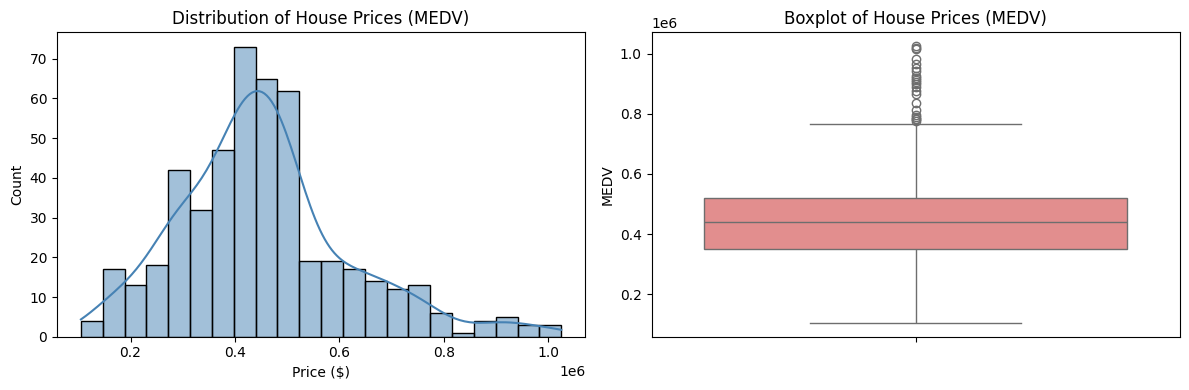

In [7]:
# Distribution of the target variable MEDV
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data['MEDV'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of House Prices (MEDV)')
axes[0].set_xlabel('Price ($)')

sns.boxplot(y=data['MEDV'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of House Prices (MEDV)')

plt.tight_layout()
plt.show()

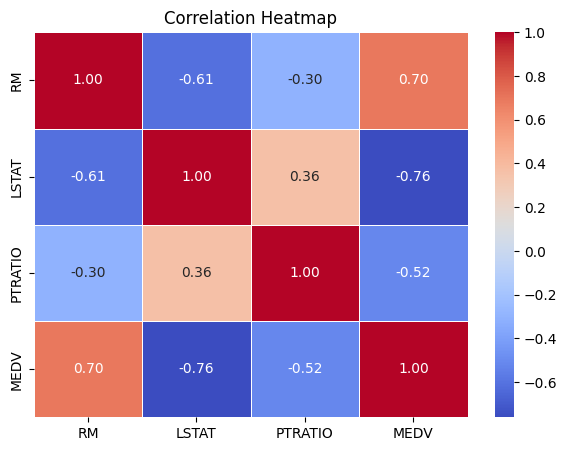

In [8]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

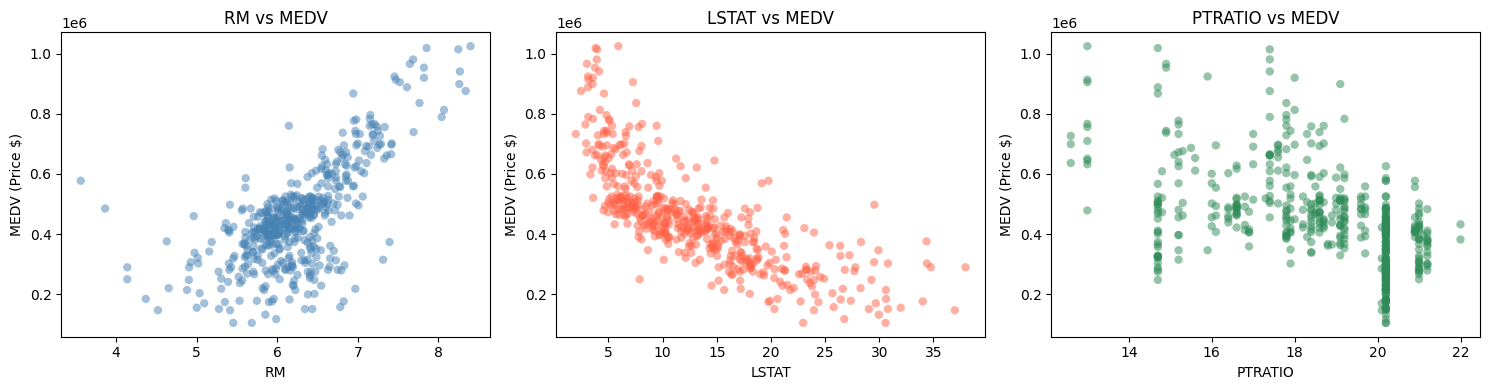

In [9]:
# Scatter plots: each feature vs MEDV
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_list = ['RM', 'LSTAT', 'PTRATIO']
colors = ['steelblue', 'tomato', 'seagreen']

for ax, feat, color in zip(axes, features_list, colors):
    ax.scatter(data[feat], data['MEDV'], alpha=0.5, color=color, edgecolors='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('MEDV (Price $)')
    ax.set_title(f'{feat} vs MEDV')

plt.tight_layout()
plt.show()

---
## 4. Prepare Data for Modeling

In [10]:
# Separate features and target
X = data.drop('MEDV', axis=1)   # Features: RM, LSTAT, PTRATIO
y = data['MEDV']                 # Target: House Price

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 391
Testing  samples : 98


---
## 5. Helper: Performance Metric

In [11]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Train a model and print key performance metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f'\n=== {name} ===')
    print(f'  R²   Score : {r2:.4f}')
    print(f'  RMSE       : ${rmse:,.0f}')
    print(f'  MAE        : ${mae:,.0f}')

    return model, y_pred, r2

---
## 6. Model 1 – Linear Regression (Baseline)

In [12]:
lr_model, lr_pred, lr_r2 = evaluate_model(
    'Linear Regression', LinearRegression(),
    X_train, X_test, y_train, y_test
)


=== Linear Regression ===
  R²   Score : 0.6911
  RMSE       : $82,396
  MAE        : $64,277


---
## 7. Model 2 – Decision Tree Regressor + GridSearchCV

Best max_depth found by GridSearchCV: 4


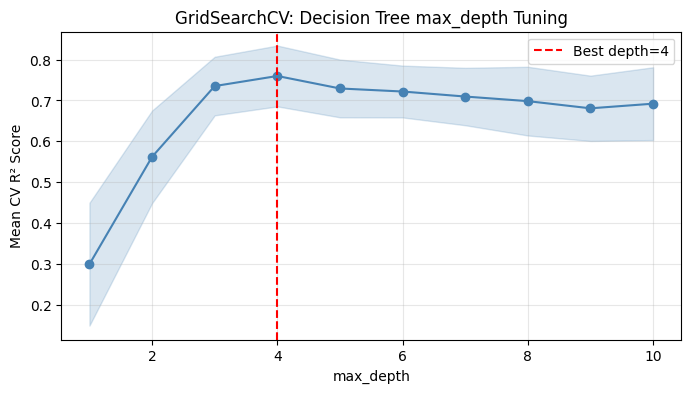

In [13]:
# Grid search to find the best max_depth
param_grid = {'max_depth': list(range(1, 11))}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_depth = grid_search.best_params_['max_depth']
print(f'Best max_depth found by GridSearchCV: {best_depth}')

# Plot R² scores for each depth
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(results['param_max_depth'], results['mean_test_score'], 'o-', color='steelblue')
plt.fill_between(
    results['param_max_depth'].astype(int),
    results['mean_test_score'] - results['std_test_score'],
    results['mean_test_score'] + results['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Mean CV R² Score')
plt.title('GridSearchCV: Decision Tree max_depth Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Evaluate best Decision Tree
dt_model, dt_pred, dt_r2 = evaluate_model(
    f'Decision Tree (max_depth={best_depth})',
    DecisionTreeRegressor(max_depth=best_depth, random_state=42),
    X_train, X_test, y_train, y_test
)


=== Decision Tree (max_depth=4) ===
  R²   Score : 0.8440
  RMSE       : $58,554
  MAE        : $45,179


---
## 8. Model 3 – Random Forest Regressor (Best Model)

In [15]:
rf_model, rf_pred, rf_r2 = evaluate_model(
    'Random Forest (100 trees)',
    RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    X_train, X_test, y_train, y_test
)


=== Random Forest (100 trees) ===
  R²   Score : 0.8597
  RMSE       : $55,526
  MAE        : $42,830


---
## 9. Model 4 – Gradient Boosting Regressor

In [16]:
gb_model, gb_pred, gb_r2 = evaluate_model(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    X_train, X_test, y_train, y_test
)


=== Gradient Boosting ===
  R²   Score : 0.8471
  RMSE       : $57,964
  MAE        : $44,875


---
## 10. Model Comparison

                  Model  R² Score
          Random Forest  0.859713
      Gradient Boosting  0.847127
Decision Tree (depth=4)  0.844000
      Linear Regression  0.691093


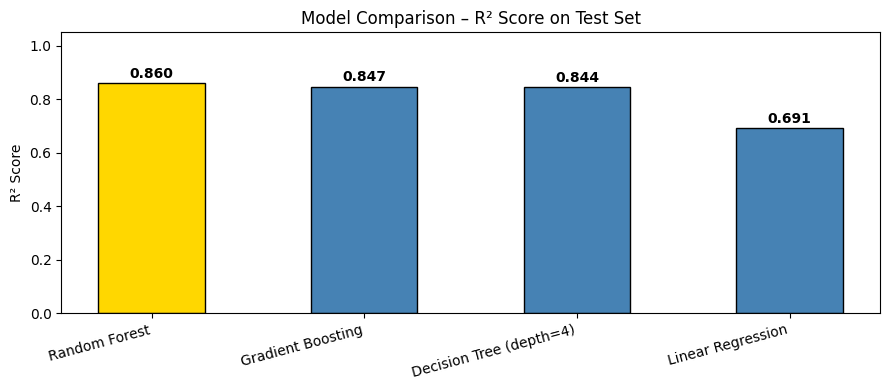

In [17]:
# Summary table
model_names = ['Linear Regression', f'Decision Tree (depth={best_depth})', 'Random Forest', 'Gradient Boosting']
r2_scores   = [lr_r2, dt_r2, rf_r2, gb_r2]

summary = pd.DataFrame({'Model': model_names, 'R² Score': r2_scores})
summary = summary.sort_values('R² Score', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 4))
colors_bar = ['gold' if s == max(r2_scores) else 'steelblue' for s in summary['R² Score']]
bars = plt.bar(summary['Model'], summary['R² Score'], color=colors_bar, edgecolor='black', width=0.5)
plt.ylim(0, 1.05)
plt.ylabel('R² Score')
plt.title('Model Comparison – R² Score on Test Set')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, summary['R² Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Best Model – Predictions vs Actual

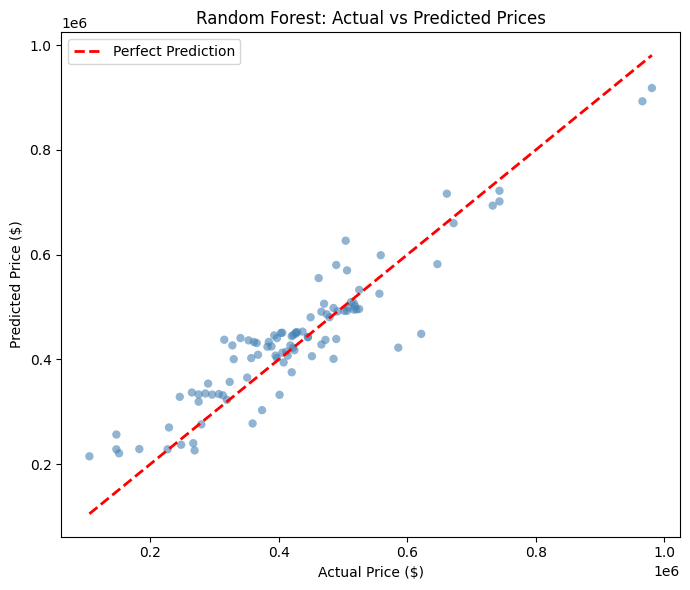

In [18]:
# Use Random Forest as best model (compare predicted vs actual)
best_pred = rf_pred
best_name = 'Random Forest'

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.6, color='steelblue', edgecolors='none')
# Perfect prediction line
line = [y_test.min(), y_test.max()]
plt.plot(line, line, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'{best_name}: Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

---
## 12. Feature Importance (Random Forest)

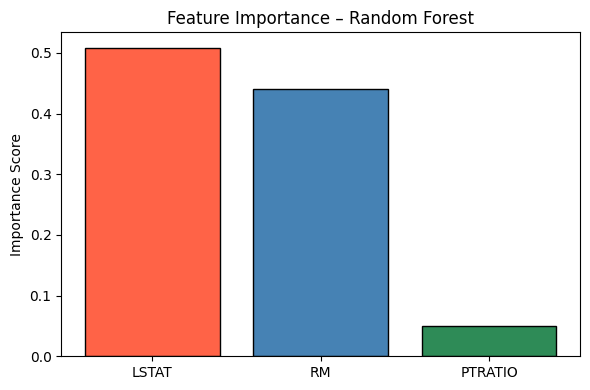

  LSTAT      : 0.5086
  RM         : 0.4407
  PTRATIO    : 0.0507


In [19]:
importances = rf_model.feature_importances_
feat_names  = X.columns.tolist()

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(6, 4))
plt.bar(
    [feat_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=['tomato', 'steelblue', 'seagreen'],
    edgecolor='black'
)
plt.ylabel('Importance Score')
plt.title('Feature Importance – Random Forest')
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f'  {feat_names[i]:<10} : {importances[i]:.4f}')

---
## 13. Make a Prediction on a New House

In [20]:
# Example: A house with 6 rooms, 10% lower-class, student-teacher ratio of 15
new_house = pd.DataFrame({
    'RM':      [6.0],
    'LSTAT':   [10.0],
    'PTRATIO': [15.0]
})

predicted_price = rf_model.predict(new_house)[0]
print(f'Predicted price for the new house: ${predicted_price:,.0f}')

Predicted price for the new house: $457,608


---
## Summary

| Model | Performance |
|---|---|
| Linear Regression | Baseline — assumes linear relationship |
| Decision Tree | Good — tuned with GridSearchCV |
| **Random Forest** | **Best — ensemble of trees, reduces overfitting** |
| Gradient Boosting | Also high accuracy, slower to train |

**Key Finding:** `LSTAT` (lower-class %) and `RM` (rooms) are the most important features for predicting house prices.